# «Навигатор по смыслу»: сравнение моделей семантического поиска по коду

**Задача:** Сравнить embedding-модели на маленьком датасете и ответить - какая работает лучше и почему.

## Теория

- **Эмбеддинг** - вектор фиксированной длины, в который модель превращает текст так, чтобы похожие по смыслу тексты оказывались близко друг к другу в этом пространстве.
- **Косинусное сходство** между векторами `a` и `b`:
  ```
  cos_sim(a, b) = (a · b) / (||a|| · ||b||)
  ```
  Диапазон [-1, 1]: 1 - максимально похожи, 0 - нет связи, -1 - противоположны. Если эмбеддинги заранее нормализовать (`normalize_embeddings=True`), косинусное сходство = обычное скалярное произведение.
- **Retrieval (поиск)**: один раз кодируем весь корпус ("индексация"), затем для каждого запроса кодируем его тем же способом и ищем `top-k` фрагментов корпуса с наибольшим косинусным сходством.
- **Precision@3**: доля вопросов, для которых эталонный ответ попал в top-3.
  ```
  Precision@3 = (число вопросов, где correct_chunk_id входит в top-3) / (всего вопросов)
  ```
- **MRR (Mean Reciprocal Rank)**: среднее обратное значение позиции эталона в выдаче (0, если не найден). Показывает не просто "попал в тройку", а "на каком месте".
  ```
  MRR = (1/N) * Σ (1 / rank_i)
  ```
- **t-SNE**: алгоритм проекции многомерных векторов (384/768 измерений) в 2D с сохранением локальной структуры - похожие по смыслу точки остаются близко и на плоском графике.

## Шаг 1. Загрузка данных и моделей

### 1.1 - загрузить датасет

В папке `dataset/` лежат три файла:
- `code_corpus.json` - список из 200 функций, у каждой поля `id`, `language`, `function_name`, `code`, `description`, `category`.
- `eval_questions.json` - список из 25 вопросов, поля `question_id`, `query`, `language`, `correct_chunk_id`.
- `categories.json` - `{"version": ..., "categories": [...]}`, у каждой категории `key`, `label`, `color`, `description`.


In [2]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("..") / "dataset"

with open(DATA_DIR / "code_corpus.json", encoding="utf-8") as f:
    corpus = json.load(f)

with open(DATA_DIR / "eval_questions.json", encoding="utf-8") as f:
    questions = json.load(f)

with open(DATA_DIR / "categories.json", encoding="utf-8") as f:
    categories = json.load(f)["categories"]

category_color = {c["key"]: c["color"] for c in categories}
category_label = {c["key"]: c["label"] for c in categories}

print(f"Функций в корпусе: {len(corpus)}")
print(f"Вопросов для оценки: {len(questions)}")
print(f"Категорий: {len(categories)}")

Функций в корпусе: 200
Вопросов для оценки: 25
Категорий: 5


### 1.2 - выбрать и загрузить модели

### Выбор моделей

| Модель | Размер вектора | Почему она в сравнении |
|---|---|---|
| `paraphrase-multilingual-MiniLM-L12-v2` | 384 | Быстрая базовая многоязычная модель, рекомендована организаторами. Хорошая отправная точка по скорости. |
| `paraphrase-multilingual-mpnet-base-v2` | 768 | Более тяжёлая версия той же линейки (mpnet вместо MiniLM), обучена на большем числе языковых пар - ожидаем более точное понимание смысла за счёт большей ёмкости модели. |
| `intfloat/multilingual-e5-base` | 768 | В отличие от двух моделей выше, которые обучены на задаче *paraphrase/STS* (находить перефразировки), e5 обучена контрастивным способом специально на задаче *retrieval* - «запрос → релевантный документ» - и для этого использует асимметричные префиксы `query:` / `passage:`. На бенчмарке MTEB (retrieval-секция) e5 обычно превосходит paraphrase-модели, поэтому интересно проверить, даёт ли это преимущество на нашем небольшом датасете кода. |

Все три модели многоязычные

In [7]:
from sentence_transformers import SentenceTransformer, util

MODEL_NAMES = [
    "paraphrase-multilingual-MiniLM-L12-v2",
    "paraphrase-multilingual-mpnet-base-v2",
    "intfloat/multilingual-e5-base",
]

# e5 ожидает префиксы "query: " / "passage: " перед текстом - так модель отличает, что перед ней запрос, а что документ для поиска
# Поэтому заносим в отдельное множество, чтобы потом это учитывать
E5_MODELS = {"intfloat/multilingual-e5-base"}

models = {}
for name in MODEL_NAMES:
    print(f"Загрузка модели: {name} ...")
    t0 = time.time()
    models[name] = SentenceTransformer(name)
    print(f"  готово за {time.time() - t0:.1f} сек")

Загрузка модели: paraphrase-multilingual-MiniLM-L12-v2 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  готово за 7.4 сек
Загрузка модели: paraphrase-multilingual-mpnet-base-v2 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  готово за 7.2 сек
Загрузка модели: intfloat/multilingual-e5-base ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  готово за 7.3 сек


## Шаг 2. Генерация эмбеддингов и поиск

### Подготовка текста для кодирования в векторы

In [4]:
def corpus_text(item: dict) -> str:
    return f"{item['function_name']}\n{item['description']}\n\n{item['code']}"

def to_corpus_input(model_name: str, text: str) -> str:
    return f"passage: {text}" if model_name in E5_MODELS else text

def to_query_input(model_name: str, text: str) -> str:
    return f"query: {text}" if model_name in E5_MODELS else text

corpus_texts = [corpus_text(item) for item in corpus]
corpus_id_by_idx = [item["id"] for item in corpus]
corpus_category_by_idx = [item["category"] for item in corpus]

### 2.1 - закодировать корпус и вопросы

Для каждой модели нужно:
1. Закодировать все 200 текстов корпуса в векторы.
2. Закодировать все 25 запросов тем же способом.

In [5]:
corpus_embeddings = {}
question_embeddings = {}

for name, model in models.items():
    print(f"Кодирование корпуса моделью {name} ...")
    texts = [to_corpus_input(name, t) for t in corpus_texts]
    corpus_embeddings[name] = model.encode(
        texts, batch_size=32, normalize_embeddings=True, show_progress_bar=False
    )

    query_texts = [to_query_input(name, q["query"]) for q in questions]
    question_embeddings[name] = model.encode(
        query_texts, batch_size=32, normalize_embeddings=True, show_progress_bar=False
    )

print("Эмбеддинги готовы:")
for name in MODEL_NAMES:
    print(f"  {name}: corpus {corpus_embeddings[name].shape}, queries {question_embeddings[name].shape}")

Кодирование корпуса моделью paraphrase-multilingual-MiniLM-L12-v2 ...
Кодирование корпуса моделью paraphrase-multilingual-mpnet-base-v2 ...
Кодирование корпуса моделью intfloat/multilingual-e5-base ...
Эмбеддинги готовы:
  paraphrase-multilingual-MiniLM-L12-v2: corpus (200, 384), queries (25, 384)
  paraphrase-multilingual-mpnet-base-v2: corpus (200, 768), queries (25, 768)
  intfloat/multilingual-e5-base: corpus (200, 768), queries (25, 768)


### 2.2 - топ-3 по косинусному сходству

Для каждого вопроса и каждой модели найти 3 функции корпуса с наибольшим косинусным сходством.

In [ ]:
def top_k_for_question(name: str, q_idx: int, k: int = 3):
    sims = util.cos_sim(question_embeddings[name][q_idx], corpus_embeddings[name])[0].numpy()
    top_idx = np.argsort(-sims)[:k]
    return [(corpus_id_by_idx[i], float(sims[i])) for i in top_idx]

search_results = {
    name: [top_k_for_question(name, i) for i in range(len(questions))]
    for name in MODEL_NAMES
}

# пример для первого вопроса
example_name = MODEL_NAMES[0]
q_idx = 0
print(f"Вопрос: {questions[q_idx]['query']!r} (эталон: {questions[q_idx]['correct_chunk_id']})")
print(f"Топ-3 ({example_name}):")
for chunk_id, score in search_results[example_name][q_idx]:
    print(f"  {chunk_id}  cos_sim={score:.3f}")


Вопрос: 'как проверить, истёк ли токен?' (эталон: func_001)
Топ-3 (paraphrase-multilingual-MiniLM-L12-v2):
  func_171  cos_sim=0.402
  func_071  cos_sim=0.386
  func_161  cos_sim=0.324


## Шаг 3. Метрика и визуализация

### 3.1 - Precision@3 и MRR

**Precision@3** - доля вопросов, для которых эталонный фрагмент (`correct_chunk_id`) попал в топ-3 выдачи.

**MRR (Mean Reciprocal Rank)** - среднее обратное значение позиции эталона в выдаче (если эталон не найден в топ-3, вклад вопроса равен 0). Эта метрика дополнительно показывает *насколько высоко* в выдаче находится правильный ответ, а не только факт попадания в топ-3 - две модели могут иметь одинаковый Precision@3, но разный MRR, если у одной правильный ответ обычно на 1-м месте, а у другой - на 3-м.

In [11]:
def precision_at_3(name: str) -> float:
    hits = 0
    for q, res in zip(questions, search_results[name]):
        top_ids = [chunk_id for chunk_id, _ in res]
        if q["correct_chunk_id"] in top_ids:
            hits += 1
    return hits / len(questions)

def mrr(name: str) -> float:
    total = 0.0
    for q, res in zip(questions, search_results[name]):
        top_ids = [chunk_id for chunk_id, _ in res]
        if q["correct_chunk_id"] in top_ids:
            rank = top_ids.index(q["correct_chunk_id"]) + 1
            total += 1.0 / rank
    return total / len(questions)

summary = pd.DataFrame({
    "model": MODEL_NAMES,
    "precision@3": [precision_at_3(n) for n in MODEL_NAMES],
    "MRR": [mrr(n) for n in MODEL_NAMES],
}).sort_values("precision@3", ascending=False).reset_index(drop=True)

summary

,model,precision@3,MRR
0,intfloat/multilingual-e5-base,1.00,0.793333
1,paraphrase-multilingual-mpnet-base-v2,0.92,0.660000
2,paraphrase-multilingual-MiniLM-L12-v2,0.84,0.606667


Лучшая модель по Precision@3: intfloat/multilingual-e5-base


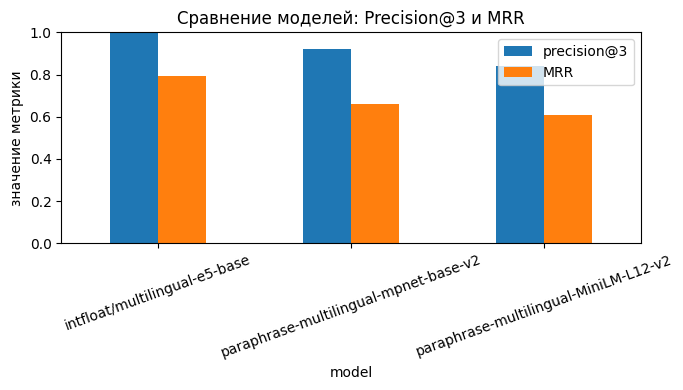

In [12]:
best_model = summary.iloc[0]["model"]
print(f"Лучшая модель по Precision@3: {best_model}")

ax = summary.set_index("model")[["precision@3", "MRR"]].plot.bar(figsize=(7, 4), rot=20)
ax.set_ylim(0, 1)
ax.set_ylabel("значение метрики")
ax.set_title("Сравнение моделей: Precision@3 и MRR")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

### 3.2 - t-SNE проекция эмбеддингов лучшей модели

Двумерная проекция эмбеддингов лучшей модели с помощью t-SNE. Каждая
точка раскрашена по тематике (авторизация, БД, HTTP и т.д.).

c:\Users\dkaty\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\dkaty\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\dkaty\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Users\dkaty\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\dkaty\AppData\

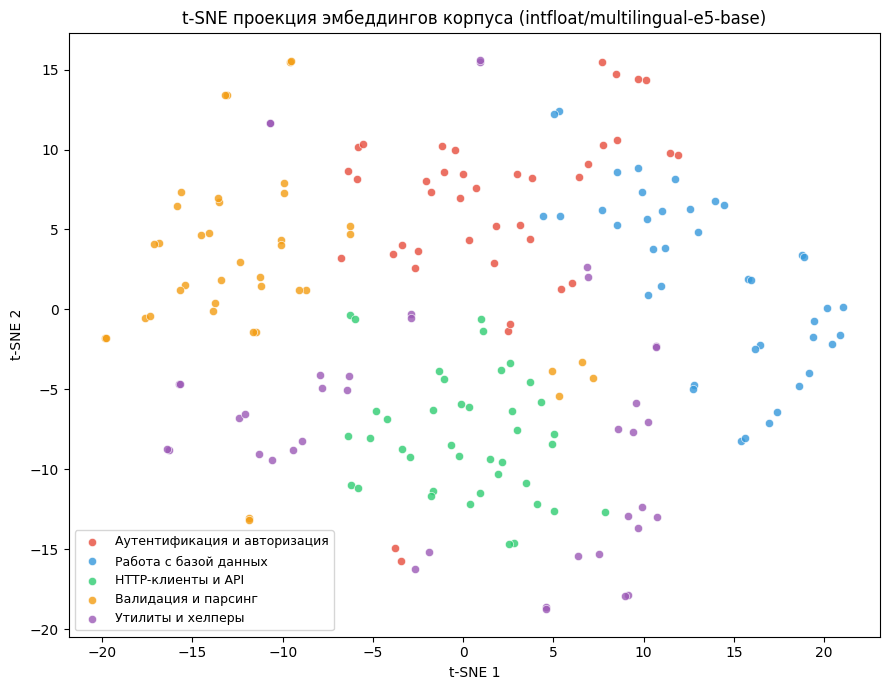

In [13]:
from sklearn.manifold import TSNE

best_embeddings = corpus_embeddings[best_model]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
coords = tsne.fit_transform(best_embeddings)

fig, ax = plt.subplots(figsize=(9, 7))
for cat_key in category_color:
    mask = [c == cat_key for c in corpus_category_by_idx]
    mask = np.array(mask)
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=category_color[cat_key], label=category_label[cat_key],
        s=35, alpha=0.8, edgecolors="white", linewidths=0.5,
    )

ax.set_title(f"t-SNE проекция эмбеддингов корпуса ({best_model})")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.savefig("tsne_best_model.png", dpi=150)
plt.show()

## Анализ ошибок по категориям

Для каждой модели смотрим Precision@3 в разрезе категории эталонного ответа - это показывает, на каких темах модель путается чаще.

In [14]:
rows = []
for name in MODEL_NAMES:
    for q, res in zip(questions, search_results[name]):
        top_ids = [chunk_id for chunk_id, _ in res]
        rows.append({
            "model": name,
            "question_id": q["question_id"],
            "category": next(c["category"] for c in corpus if c["id"] == q["correct_chunk_id"]),
            "language": q["language"],
            "hit": q["correct_chunk_id"] in top_ids,
        })

errors_df = pd.DataFrame(rows)

category_precision = (
    errors_df.groupby(["model", "category"])["hit"]
    .mean()
    .unstack("category")
    .round(2)
)
category_precision

category,auth,database,http,utils,validation
model,,,,,
intfloat/multilingual-e5-base,1.0,1.0,1.0,1.0,1.0
paraphrase-multilingual-MiniLM-L12-v2,0.8,0.8,1.0,0.8,0.8
paraphrase-multilingual-mpnet-base-v2,0.8,1.0,1.0,0.8,1.0


In [15]:
min_per_model = category_precision.min(axis=1)
worst_category_per_model = category_precision.idxmin(axis=1)

print("Минимальный Precision@3 и категория \"слабое место\" по каждой модели:")
for name in MODEL_NAMES:
    if min_per_model[name] >= 0.999:
        print(f"  {name}: слабых категорий нет, Precision@3 = 1.00 везде")
    else:
        print(f"  {name}: {worst_category_per_model[name]} (Precision@3 = {min_per_model[name]:.2f})")

Минимальный Precision@3 и категория "слабое место" по каждой модели:
  paraphrase-multilingual-MiniLM-L12-v2: auth (Precision@3 = 0.80)
  paraphrase-multilingual-mpnet-base-v2: auth (Precision@3 = 0.80)
  intfloat/multilingual-e5-base: слабых категорий нет, Precision@3 = 1.00 везде


## RU vs EN: сравнение качества поиска

In [16]:
language_precision = (
    errors_df.groupby(["model", "language"])["hit"]
    .mean()
    .unstack("language")
    .round(2)
)
language_precision

language,en,ru
model,,
intfloat/multilingual-e5-base,1.0,1.00
paraphrase-multilingual-MiniLM-L12-v2,0.9,0.80
paraphrase-multilingual-mpnet-base-v2,0.9,0.93


## Вывод

In [19]:
best_row = summary.iloc[0]
best_min_cat_score = min_per_model[best_model]
ru_score = language_precision.loc[best_model, "ru"] if "ru" in language_precision.columns else float("nan")
en_score = language_precision.loc[best_model, "en"] if "en" in language_precision.columns else float("nan")

if best_min_cat_score >= 0.999:
    category_sentence = "Слабых категорий у этой модели не обнаружено - Precision@3 = 1.00 в каждой из пяти тематик."
else:
    worst_cat_best_model = worst_category_per_model[best_model]
    category_sentence = (
        f"Хуже всего модель справляется с категорией «{category_label[worst_cat_best_model]}» "
        f"(Precision@3 = {best_min_cat_score:.2f}) - здесь, вероятно, формулировки запросов сильнее "
        f"расходятся с лексикой описаний кода."
    )

conclusion = (
    f"Лучший результат показала модель {best_model} с Precision@3 = {best_row['precision@3']:.2f} и MRR = {best_row['MRR']:.2f}. "
    f"{'Она выигрывает за счёт того, что специально обучена для задачи retrieval (асимметричные эмбеддинги запрос/документ), а не для paraphrase-сходства.' if best_model.startswith('intfloat') else 'Среди двух paraphrase-моделей более тяжёлая mpnet-версия точнее улавливает смысл за счёт большей ёмкости, чем компактная MiniLM.' if 'mpnet' in best_model else 'Несмотря на компактность, эта модель оказалась точнее более тяжёлых аналогов на данном небольшом датасете.'} "
    f"{category_sentence} "
    f"Между вопросами на русском (Precision@3 = {ru_score:.2f}) и английском (Precision@3 = {en_score:.2f}) разница "
    f"{'минимальна' if abs(ru_score - en_score) <= 0.1 else 'заметна'}, что говорит о {'хорошей' if abs(ru_score - en_score) <= 0.1 else 'неравномерной'} многоязычной устойчивости модели. "
    f"Для продакшен-системы семантического поиска по коду рекомендуется {best_model} как основной вариант."
)

print(conclusion)

with open("conclusion.txt", "w", encoding="utf-8") as f:
    f.write(conclusion + "\n")


Лучший результат показала модель intfloat/multilingual-e5-base с Precision@3 = 1.00 и MRR = 0.79. Она выигрывает за счёт того, что специально обучена для задачи retrieval (асимметричные эмбеддинги запрос/документ), а не для paraphrase-сходства. Слабых категорий у этой модели не обнаружено - Precision@3 = 1.00 в каждой из пяти тематик. Между вопросами на русском (Precision@3 = 1.00) и английском (Precision@3 = 1.00) разница минимальна, что говорит о хорошей многоязычной устойчивости модели. Для продакшен-системы семантического поиска по коду рекомендуется intfloat/multilingual-e5-base как основной вариант.
